# **A Mixed-Methods Analysis of Repression and Mobilization in Bangladesh's July Revolution**

This notebook contains the full ML & Regression Analysis codes using the ACLED dataset during the July Revolution.

## **Installing & Importing Libraries**

In [2]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.8 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestRegressor
from linearmodels.panel import PanelOLS
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller
from xgboost import XGBRegressor
import textwrap
import joblib

# **Pooled OLS Regression**

In [ ]:
# --- Loading and preparing data ---
df = pd.read_csv('/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_division_dataset.csv', parse_dates=['event_date'])
df = df.sort_values(['admin1', 'event_date'])

# --- Feature engineering ---
def create_features(data):
    df = data.copy()
    df['prev_day_fatalities'] = df.groupby('admin1')['total_fatalities'].shift(1)
    df['prev_day_events'] = df.groupby('admin1')['total_events'].shift(1)
    df['elsewhere_fatalities'] = df.groupby('event_date')['total_fatalities'].transform('sum') - df['total_fatalities']
    df['elsewhere_events'] = df.groupby('event_date')['total_events'].transform('sum') - df['total_events']
    df['days_since_start'] = (df['event_date'] - df['event_date'].min()).dt.days
    sqrt_features = ['prev_day_fatalities', 'elsewhere_fatalities',
                    'prev_day_events', 'elsewhere_events']
    for col in sqrt_features:
        df[f'sqrt_{col}'] = np.sqrt(df[col])
    # Rescaling population to prevent convergence errors
    df['population_in_millions'] = df['population'] / 1_000_000
    df = df.drop('population', axis=1)
    return df.dropna()

model_df = create_features(df)
X = model_df[[
    'sqrt_prev_day_fatalities', 'sqrt_elsewhere_fatalities',
    'sqrt_prev_day_events', 'sqrt_elsewhere_events',
    'days_since_start', 'population_in_millions'
]]
y = np.sqrt(model_df['total_events'])


# --- VIF CALCULATION ---
# Preparing the DataFrame for VIF calculation
X_for_vif = X.copy()
X_for_vif['const'] = 1 # VIF needs a constant

# Calculating and displaying VIF
print("="*80)
print("Variance Inflation Factor (VIF) Calculation")
print("="*80)
vif_data = pd.DataFrame()
vif_data["feature"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(len(X_for_vif.columns))]
vif_data = vif_data[vif_data['feature'] != 'const']
print(vif_data)
print("\n--- VIF Interpretation ---")
print("VIF > 5 or 10 suggests high multicollinearity.")
print("="*80, "\n\n")


# --- OLS Report ---
X_const = sm.add_constant(X)
ols_model = sm.OLS(y, X_const).fit()
print(ols_model.summary())


# --- Feature Legend ---
print("\nFeature Legend:")
print("const: Intercept")
print("sqrt_prev_day_fatalities: √Fatalities(t-1, division)")
print("sqrt_elsewhere_fatalities: √Fatalities(t-1, elsewhere)")
print("sqrt_prev_day_events: √Events(t-1, division)")
print("sqrt_elsewhere_events: √Events(t-1, elsewhere)")
print("days_since_start: Time Trend (T)")
print("population: Population")


# --- Cross-Validation Metrics ---
tscv = TimeSeriesSplit(n_splits=5)
preds = np.full_like(y, np.nan)
for train_idx, test_idx in tscv.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model = LinearRegression().fit(X_train, y_train)
    preds[test_idx] = model.predict(X_test)

mask = ~np.isnan(preds)
y_true = y[mask]
y_pred = preds[mask]

print("\n\n")
print("="*80)
print("Cross-Validation Metrics")
print("="*80)
print(f'R²: {r2_score(y_true, y_pred):.3f}')
print(f'MAE: {mean_absolute_error(y_true, y_pred):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}')


# --- Retransformed Metrics ---
y_true_raw = y_true ** 2
y_pred_raw = y_pred ** 2
print("\n" + "="*80)
print("OLS Cross-Validation Metrics on COMPARABLE Raw Count Scale")
print("="*80)
print(f'MAE on raw counts: {mean_absolute_error(y_true_raw, y_pred_raw):.3f}')
print(f'RMSE on raw counts: {np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)):.3f}')

Variance Inflation Factor (VIF) Calculation
                     feature       VIF
0   sqrt_prev_day_fatalities  1.707856
1  sqrt_elsewhere_fatalities  3.338909
2       sqrt_prev_day_events  2.381235
3      sqrt_elsewhere_events  3.827054
4           days_since_start  1.347873
5     population_in_millions  1.533750

--- VIF Interpretation ---
VIF > 5 or 10 suggests high multicollinearity.


                            OLS Regression Results                            
Dep. Variable:           total_events   R-squared:                       0.592
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     116.5
Date:                Sat, 13 Sep 2025   Prob (F-statistic):           1.87e-90
Time:                        21:46:27   Log-Likelihood:                -484.37
No. Observations:                 488   AIC:                             982.7
Df Residuals:                     481   BIC:         

# **Negative Binomial Regression**

In [ ]:
# --- Loading and preparing data ---
df = pd.read_csv('/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_division_dataset.csv', parse_dates=['event_date'])
df = df.sort_values(['admin1', 'event_date'])

# --- Feature engineering ---
def create_features(data):
    df = data.copy()
    df['prev_day_fatalities'] = df.groupby('admin1')['total_fatalities'].shift(1)
    df['prev_day_events'] = df.groupby('admin1')['total_events'].shift(1)
    df['elsewhere_fatalities'] = df.groupby('event_date')['total_fatalities'].transform('sum') - df['total_fatalities']
    df['elsewhere_events'] = df.groupby('event_date')['total_events'].transform('sum') - df['total_events']
    df['days_since_start'] = (df['event_date'] - df['event_date'].min()).dt.days
    sqrt_features = ['prev_day_fatalities', 'elsewhere_fatalities',
                    'prev_day_events', 'elsewhere_events']
    for col in sqrt_features:
        df[f'sqrt_{col}'] = np.sqrt(df[col])
    return df.dropna()

model_df = create_features(df)

# --- Preparing data for NEGATIVE BINOMIAL model ---
# Using the original UNTRANSFORMED count for the dependent variable
y_nb = model_df['total_events']

# Using the same independent variables as OLS
X_nb = model_df[[
    'sqrt_prev_day_fatalities', 'sqrt_elsewhere_fatalities',
    'sqrt_prev_day_events', 'sqrt_elsewhere_events',
    'days_since_start', 'population'
]].copy()

# Rescaling population to prevent convergence errors
X_nb['population_in_millions'] = X_nb['population'] / 1_000_000
X_nb = X_nb.drop('population', axis=1)

# Adding constant for intercept
X_const_nb = sm.add_constant(X_nb)


# --- Fitting NEGATIVE BINOMIAL model with a ROBUST two-step method ---
# Step 2a: Fitting a simpler Poisson model to get good starting values
print("--- Step 1: Fitting Poisson to find a good starting point ---")
poisson_model_for_start = sm.Poisson(y_nb, X_const_nb).fit(disp=0)
start_params = poisson_model_for_start.params
# We also need a starting value for 'alpha', the NB dispersion parameter
start_params['alpha'] = 1.0
print("Found starting parameters.")

# Step 2b: Fitting the Negative Binomial model using the starting values
print("--- Step 2: Fitting Negative Binomial model with warm start ---")
nb_model = sm.NegativeBinomial(y_nb, X_const_nb).fit(
    start_params=start_params,
    method='bfgs',
    maxiter=5000
)

print("\n===================================================================================")
print("Pooled Negative Binomial Regression Results")
print("===================================================================================")
print(nb_model.summary())


# --- Adding IRR interpretation ---
print("\n--- Incidence Rate Ratios (IRR) ---")
irr = np.exp(nb_model.params)
print(irr)

print("\n--- IRR Confidence Intervals ---")
irr_conf_int = np.exp(nb_model.conf_int())
irr_conf_int.columns = ['IRR Lower CI', 'IRR Upper CI']
print(irr_conf_int)


# --- Updating Cross-Validation for NEGATIVE BINOMIAL ---
print("\n\n")
print("="*80)
print("Cross-Validation Metrics for Negative Binomial Model")
print("="*80)

tscv = TimeSeriesSplit(n_splits=5)
# Using y_nb and X_const_nb for the loop
preds = np.full_like(y_nb, np.nan, dtype=float)

for train_idx, test_idx in tscv.split(X_const_nb):
    X_train, X_test = X_const_nb.iloc[train_idx], X_const_nb.iloc[test_idx]
    y_train = y_nb.iloc[train_idx]

    # Fitting a statsmodels Negative Binomial model in the loop
    try:
        model = sm.NegativeBinomial(y_train, X_train).fit(disp=0)
        preds[test_idx] = model.predict(X_test)
    except Exception as e:
        print(f"A fold in cross-validation failed to converge: {e}")
        # If a fold fails, we can't make predictions for it
        preds[test_idx] = np.nan


# Metrics
mask = ~np.isnan(preds)
y_true = y_nb[mask]
y_pred = preds[mask]

# Note: R² is not a standard metric for count models. MAE and RMSE are more direct.
print(f'R²: {r2_score(y_true, y_pred):.3f}')
print(f'MAE: {mean_absolute_error(y_true, y_pred):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}')

--- Step 1: Fitting Poisson to find a good starting point ---
Found starting parameters.
--- Step 2: Fitting Negative Binomial model with warm start ---
Optimization terminated successfully.
         Current function value: 1.293680
         Iterations: 21
         Function evaluations: 26
         Gradient evaluations: 26

Pooled Negative Binomial Regression Results
                     NegativeBinomial Regression Results                      
Dep. Variable:           total_events   No. Observations:                  488
Model:               NegativeBinomial   Df Residuals:                      481
Method:                           MLE   Df Model:                            6
Date:                Sun, 31 Aug 2025   Pseudo R-squ.:                  0.2449
Time:                        11:00:05   Log-Likelihood:                -631.32
converged:                       True   LL-Null:                       -836.11
Covariance Type:            nonrobust   LLR p-value:                 2.423e-8

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-p

## **Applying Log Transformation to Population**

In [ ]:
# --- Loading and preparing data ---
df = pd.read_csv('/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_division_dataset.csv', parse_dates=['event_date'])
df = df.sort_values(['admin1', 'event_date'])

# --- Feature engineering ---
def create_features(data):
    df = data.copy()
    df['prev_day_fatalities'] = df.groupby('admin1')['total_fatalities'].shift(1)
    df['prev_day_events'] = df.groupby('admin1')['total_events'].shift(1)
    df['elsewhere_fatalities'] = df.groupby('event_date')['total_fatalities'].transform('sum') - df['total_fatalities']
    df['elsewhere_events'] = df.groupby('event_date')['total_events'].transform('sum') - df['total_events']
    df['days_since_start'] = (df['event_date'] - df['event_date'].min()).dt.days
    sqrt_features = ['prev_day_fatalities', 'elsewhere_fatalities',
                    'prev_day_events', 'elsewhere_events']
    for col in sqrt_features:
        df[f'sqrt_{col}'] = np.sqrt(df[col])
    return df.dropna()

model_df = create_features(df)

# --- Preparing data for NEGATIVE BINOMIAL model ---
y_nb = model_df['total_events']

# Use the same independent variables as OLS, but using log-transformed population
X_nb = model_df[[
    'sqrt_prev_day_fatalities', 'sqrt_elsewhere_fatalities',
    'sqrt_prev_day_events', 'sqrt_elsewhere_events',
    'days_since_start', 'population'
]].copy()

# Applying a log transformation to the population variable.
X_nb['log_population'] = np.log(X_nb['population'])
X_nb = X_nb.drop('population', axis=1) # Drop the original column

# Adding constant for intercept
X_const_nb = sm.add_constant(X_nb)


# --- Fitting NEGATIVE BINOMIAL model with a ROBUST two-step method ---
print("--- Step 1: Fitting Poisson to find a good starting point ---")
poisson_model_for_start = sm.Poisson(y_nb, X_const_nb).fit(disp=0)
start_params = poisson_model_for_start.params
start_params['alpha'] = 1.0
print("Found starting parameters.")

print("--- Step 2: Fitting Negative Binomial model with warm start ---")
nb_model = sm.NegativeBinomial(y_nb, X_const_nb).fit(
    start_params=start_params,
    method='bfgs',
    maxiter=5000
)

print("\n===================================================================================")
print("Pooled Negative Binomial Regression Results (with Log-Population)")
print("===================================================================================")
print(nb_model.summary())


# --- Adding IRR interpretation ---
print("\n--- Incidence Rate Ratios (IRR) ---")
irr = np.exp(nb_model.params)
print(irr)
print("\nNOTE: The IRR for 'log_population' is the multiplicative effect for a one-unit increase in the log of population.")

print("\n--- IRR Confidence Intervals ---")
irr_conf_int = np.exp(nb_model.conf_int())
irr_conf_int.columns = ['IRR Lower CI', 'IRR Upper CI']
print(irr_conf_int)


# --- Updating Cross-Validation ---
print("\n\n")
print("="*80)
print("Cross-Validation Metrics for Negative Binomial Model (with Log-Population)")
print("="*80)

tscv = TimeSeriesSplit(n_splits=5)
preds = np.full_like(y_nb, np.nan, dtype=float)

for train_idx, test_idx in tscv.split(X_const_nb):
    X_train, X_test = X_const_nb.iloc[train_idx], X_const_nb.iloc[test_idx]
    y_train = y_nb.iloc[train_idx]

    try:
        model = sm.NegativeBinomial(y_train, X_train).fit(disp=0)
        preds[test_idx] = model.predict(X_test)
    except Exception as e:
        print(f"A fold in cross-validation failed to converge: {e}")
        preds[test_idx] = np.nan

mask = ~np.isnan(preds)
y_true = y_nb[mask]
y_pred = preds[mask]

print(f'R²: {r2_score(y_true, y_pred):.3f}')
print(f'MAE: {mean_absolute_error(y_true, y_pred):.3f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.3f}')

--- Step 1: Fitting Poisson to find a good starting point ---
Found starting parameters.
--- Step 2: Fitting Negative Binomial model with warm start ---
Optimization terminated successfully.
         Current function value: 1.311141
         Iterations: 29
         Function evaluations: 36
         Gradient evaluations: 36

Pooled Negative Binomial Regression Results (with Log-Population)
                     NegativeBinomial Regression Results                      
Dep. Variable:           total_events   No. Observations:                  488
Model:               NegativeBinomial   Df Residuals:                      481
Method:                           MLE   Df Model:                            6
Date:                Wed, 08 Oct 2025   Pseudo R-squ.:                  0.2347
Time:                        05:00:20   Log-Likelihood:                -639.84
converged:                       True   LL-Null:                       -836.11
Covariance Type:            nonrobust   LLR p-value:   

/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: divide by zero encountered in log
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/discrete/discrete_model.py:3379: RuntimeWarning: invalid value encountered in multiply
  llf = coeff + size*np.log(prob) + endog*np.log(1-prob)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R²: 0.422
MAE: 1.449
RMSE: 3.333


# **Fixed Effects Panel Regression**

In [ ]:
# --- Data Loading ---
df = pd.read_csv('/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_division_dataset.csv',
                 parse_dates=['event_date'])
df = df.sort_values(['admin1', 'event_date'])

# Feature engineering
def create_features(data):
    df = data.copy()
    df['prev_day_fatalities'] = df.groupby('admin1')['total_fatalities'].shift(1)
    df['prev_day_events'] = df.groupby('admin1')['total_events'].shift(1)
    df['elsewhere_fatalities'] = df.groupby('event_date')['total_fatalities'].transform('sum') - df['total_fatalities']
    df['elsewhere_events'] = df.groupby('event_date')['total_events'].transform('sum') - df['total_events']
    df['days_since_start'] = (df['event_date'] - df['event_date'].min()).dt.days
    sqrt_features = ['prev_day_fatalities', 'elsewhere_fatalities',
                    'prev_day_events', 'elsewhere_events']
    for col in sqrt_features:
        df[f'sqrt_{col}'] = np.sqrt(df[col])
    return df.dropna()

model_df = create_features(df)
# ------------------------------------------------

# 2. Data Preparation for PanelOLS
panel_data = model_df.set_index(['admin1', 'event_date'])

# 3. Dependent & Independent Variables
# Dependent variable (y)
y = np.sqrt(panel_data['total_events'])

# Independent variables (X)
# REMOVED the absorbed variables: const, population, days_since_start, and the 'elsewhere' variables. [Running with these variables would reveal the absorption]
# The constant is added automatically by PanelOLS unless explicitly told not to.
exog_vars = [
    'sqrt_prev_day_fatalities',
    'sqrt_prev_day_events'
]
X = panel_data[exog_vars]

# 4. Fitting Fixed Effects Panel OLS Model
model = PanelOLS(y, X, entity_effects=True, time_effects=True)

fe_results = model.fit()

print("===================================================================================")
print("Refined Two-Way Fixed Effects Panel Regression Results")
print("===================================================================================")
print(fe_results)

# --- Feature Legend (for clarity) ---
print("\nFeature Legend:")
print("Dep. Variable: √Total Events in a division on a given day")
print("sqrt_prev_day_fatalities: √Fatalities(t-1, same division)")
print("sqrt_prev_day_events: √Events(t-1, same division)")
print("\n--- Model Notes ---")
print("Entity Effects (Fixed Effects for 'admin1'): YES")
print("Time Effects (Fixed Effects for 'event_date'): YES")
print("This model controls for stable differences between divisions (e.g., population) AND for nationwide daily shocks.")

Refined Two-Way Fixed Effects Panel Regression Results
                          PanelOLS Estimation Summary                           
Dep. Variable:           total_events   R-squared:                        0.0843
Estimator:                   PanelOLS   R-squared (Between):              0.2569
No. Observations:                 488   R-squared (Within):               0.1580
Date:                Fri, Sep 05 2025   R-squared (Overall):              0.2124
Time:                        19:35:59   Log-likelihood                   -398.00
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      19.229
Entities:                           8   P-value                           0.0000
Avg Obs:                       61.000   Distribution:                   F(2,418)
Min Obs:                       61.000                                           
Max Obs:                       61.000   F-statistic (r

# **Structural Break Analysis using Two-Way Fixed Effects PanelOLS**

## **Cutoff: 16th July, 2024**

In [ ]:
# --- 1. Data Preparation for the Structural Break Analysis ---
cutoff_date = pd.to_datetime('2024-07-16')

# Creating the dummy variable for the "post-event" period
model_df['post_july16'] = (model_df['event_date'] >= cutoff_date).astype(int)

# Creating the new interaction term
model_df['interaction_fatalities_post16'] = model_df['post_july16'] * model_df['sqrt_prev_day_fatalities']

# Preparing the data for PanelOLS, setting the index# --- 1. Data Preparation for the Structural Break Analysis ---
panel_data_break = model_df.set_index(['admin1', 'event_date'])

# --- 2. Defining Variables for the PanelOLS Model ---
y = np.sqrt(panel_data_break['total_events'])

# Independent variables (X)
exog_vars_break = [
    'sqrt_prev_day_fatalities',
    'interaction_fatalities_post16', # Using the new interaction term
    'sqrt_prev_day_events'
]
X = panel_data_break[exog_vars_break]

# --- 3. Fitting the Revised Fixed Effect Model ---
print("="*80)
print("Structural Break Analysis (Cutoff: July 16th) using Two-Way Fixed Effects PanelOLS")
print("="*80)
model_break = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results_break = model_break.fit()

print(fe_results_break)

# --- 4. Results Interpretation ---
print("\n" + "="*80)
print("How to Interpret the Coefficients (Cutoff: July 16th):")
print("="*80)
try:
    pre_effect = fe_results_break.params['sqrt_prev_day_fatalities']
    interaction_effect = fe_results_break.params['interaction_fatalities_post16']
    post_effect = pre_effect + interaction_effect

    pre_pvalue = fe_results_break.pvalues['sqrt_prev_day_fatalities']
    interaction_pvalue = fe_results_break.pvalues['interaction_fatalities_post16']

    print(f"\n1. Effect of Suppression BEFORE July 16th:")
    print(f"   - Coefficient: {pre_effect:.4f} (p-value: {pre_pvalue:.4f})")

    print(f"\n2. The CHANGE in the effect ON/AFTER July 16th:")
    print(f"   - Coefficient (Interaction Term): {interaction_effect:.4f} (p-value: {interaction_pvalue:.4f})")
    print(f"   - Interpretation: If this is positive and significant, it proves the backfire effect became STRONGER.")

    print(f"\n3. TOTAL Effect of Suppression ON/AFTER July 16th:")
    print(f"   - Total Coefficient: {pre_effect:.4f} + {interaction_effect:.4f} = {post_effect:.4f}")

except KeyError:
    print("Could not extract all coefficients, please check the summary table above.")

Structural Break Analysis (Cutoff: July 16th) using Two-Way Fixed Effects PanelOLS
                          PanelOLS Estimation Summary                           
Dep. Variable:           total_events   R-squared:                        0.0989
Estimator:                   PanelOLS   R-squared (Between):              0.2521
No. Observations:                 488   R-squared (Within):               0.1877
Date:                Fri, Sep 05 2025   R-squared (Overall):              0.2231
Time:                        19:41:05   Log-likelihood                   -394.05
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      15.261
Entities:                           8   P-value                           0.0000
Avg Obs:                       61.000   Distribution:                   F(3,417)
Min Obs:                       61.000                                           
Max Obs:                  

## **Cutoff: 19th July, 2024**

In [ ]:
# --- 1. Data Preparation for the Structural Break Analysis ---
cutoff_date = pd.to_datetime('2024-07-19')

# Creating the dummy variable for the "post-event" period
model_df['post_july19'] = (model_df['event_date'] >= cutoff_date).astype(int)

# Creating the new interaction term
model_df['interaction_fatalities_post19'] = model_df['post_july19'] * model_df['sqrt_prev_day_fatalities']

# Preparing the data for PanelOLS, setting the index
panel_data_break = model_df.set_index(['admin1', 'event_date'])

# --- 2. Defining Variables for the PanelOLS Model ---
y = np.sqrt(panel_data_break['total_events'])

# Independent variables (X)
exog_vars_break = [
    'sqrt_prev_day_fatalities',
    'interaction_fatalities_post19', # Using the new interaction term
    'sqrt_prev_day_events'
]
X = panel_data_break[exog_vars_break]

# --- 3. Fitting the Revised Fixed Effect Model ---
print("="*80)
print("Structural Break Analysis (Cutoff: July 19th) using Two-Way Fixed Effects PanelOLS")
print("="*80)
model_break = PanelOLS(y, X, entity_effects=True, time_effects=True)
fe_results_break = model_break.fit()

print(fe_results_break)

# --- 4. Results Interpretation ---
print("\n" + "="*80)
print("How to Interpret the Coefficients (Cutoff: July 19th):")
print("="*80)
try:
    pre_effect = fe_results_break.params['sqrt_prev_day_fatalities']
    interaction_effect = fe_results_break.params['interaction_fatalities_post19']
    post_effect = pre_effect + interaction_effect

    pre_pvalue = fe_results_break.pvalues['sqrt_prev_day_fatalities']
    interaction_pvalue = fe_results_break.pvalues['interaction_fatalities_post19']

    print(f"\n1. Effect of Suppression BEFORE July 19th:")
    print(f"   - Coefficient: {pre_effect:.4f} (p-value: {pre_pvalue:.4f})")

    print(f"\n2. The CHANGE in the effect ON/AFTER July 19th:")
    print(f"   - Coefficient (Interaction Term): {interaction_effect:.4f} (p-value: {interaction_pvalue:.4f})")
    print(f"   - Interpretation: If this is positive and significant, it proves the backfire effect became STRONGER.")

    print(f"\n3. TOTAL Effect of Suppression ON/AFTER July 19th:")
    print(f"   - Total Coefficient: {pre_effect:.4f} + {interaction_effect:.4f} = {post_effect:.4f}")

except KeyError:
    print("Could not extract all coefficients, please check the summary table above.")

Structural Break Analysis (Cutoff: July 19th) using Two-Way Fixed Effects PanelOLS
                          PanelOLS Estimation Summary                           
Dep. Variable:           total_events   R-squared:                        0.0918
Estimator:                   PanelOLS   R-squared (Between):              0.2540
No. Observations:                 488   R-squared (Within):               0.1788
Date:                Fri, Sep 05 2025   R-squared (Overall):              0.2202
Time:                        19:52:18   Log-likelihood                   -395.97
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      14.056
Entities:                           8   P-value                           0.0000
Avg Obs:                       61.000   Distribution:                   F(3,417)
Min Obs:                       61.000                                           
Max Obs:                  

# **VAR Analysis**

In [ ]:
# Helper Function
def adf_test(series, title=''):
    """
    Perform Augmented Dickey-Fuller test and print results.
    """
    print(f'\nADF Test: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    labels = ['ADF Statistic', 'p-value', '# Lags Used', '# Observations Used']
    for value, label in zip(result[:4], labels):
        print(f'{label} : {value}')
    if result[1] <= 0.05:
        print("=> Stationary (reject H0)")
    else:
        print("=> Non-stationary (fail to reject H0)")

# --- Loading the National-level Daily Time Series Data ---
try:
    national_df = pd.read_csv('/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_event_summary_with_new_columns.csv', parse_dates=['event_date'], index_col='event_date')
except FileNotFoundError:
    print("Please replace with the correct path to your national-level daily summary CSV.")
    dates = pd.date_range(start='2024-06-05', end='2024-08-05', freq='D')
    national_df = pd.DataFrame(index=dates)
    national_df['total_fatalities'] = np.random.randint(0, 10, size=len(national_df))
    # Creating a combined mobilization variable
    national_df['mobilization_events'] = np.random.randint(0, 20, size=len(national_df))


# --- Data Preparation for VAR ---
# Using 'Protests' and 'Riots'as Mobilization Variables:
if 'Protests' in national_df.columns and 'Riots' in national_df.columns:
    national_df['mobilization_events'] = national_df['Protests'] + national_df['Riots']

# Selecting the core variables for the VAR model
var_data = national_df[['total_fatalities', 'mobilization_events']].dropna()


# --- TAKING THE DIFFERENCE OF THE DATA TO ACHIEVE STATIONARITY ---
var_data_stationary = national_df[['total_fatalities', 'mobilization_events']].diff().dropna()
var_data_stationary.columns = ['fatalities_change', 'mobilization_change']

print("--- ADF Tests on DIFFERENCED Data ---")
adf_test(var_data_stationary['fatalities_change'], 'Change in Fatalities')
adf_test(var_data_stationary['mobilization_change'], 'Change in Mobilization')

# --- STEP 2: Re-selecting the optimal lag order on the stationary data ---
model_stationary = VAR(var_data_stationary)
lag_selection_results = model_stationary.select_order(maxlags=10)
print("\n--- Lag Order Selection on DIFFERENCED Data ---")
print(lag_selection_results.summary())
selected_lag = lag_selection_results.aic


# --- STEP 3: Fitting the Corrected VAR model ---
print(f"\nFitting VAR model with {selected_lag} lags on DIFFERENCED data...")
results_stationary = model_stationary.fit(selected_lag)
print(results_stationary.summary())

--- ADF Tests on DIFFERENCED Data ---

ADF Test: Change in Fatalities
ADF Statistic : -3.065995420405897
p-value : 0.029174184097874374
# Lags Used : 1
# Observations Used : 57
=> Stationary (reject H0)

ADF Test: Change in Mobilization
ADF Statistic : -5.728791355346256
p-value : 6.674643763516674e-07
# Lags Used : 0
# Observations Used : 58
=> Stationary (reject H0)

--- Lag Order Selection on DIFFERENCED Data ---
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        10.52       10.59   3.693e+04       10.55
1        9.647      9.879*   1.549e+04      9.735*
2        9.729       10.12   1.682e+04       9.875
3        9.766       10.31   1.749e+04       9.971
4        9.613       10.31   1.509e+04       9.877
5        9.760       10.61   1.760e+04       10.08
6        9.846       10.85   1.938e+04       10.23
7        9.620       10.78   1.569e+04       10.06
8        9.431     

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## **Visualization**

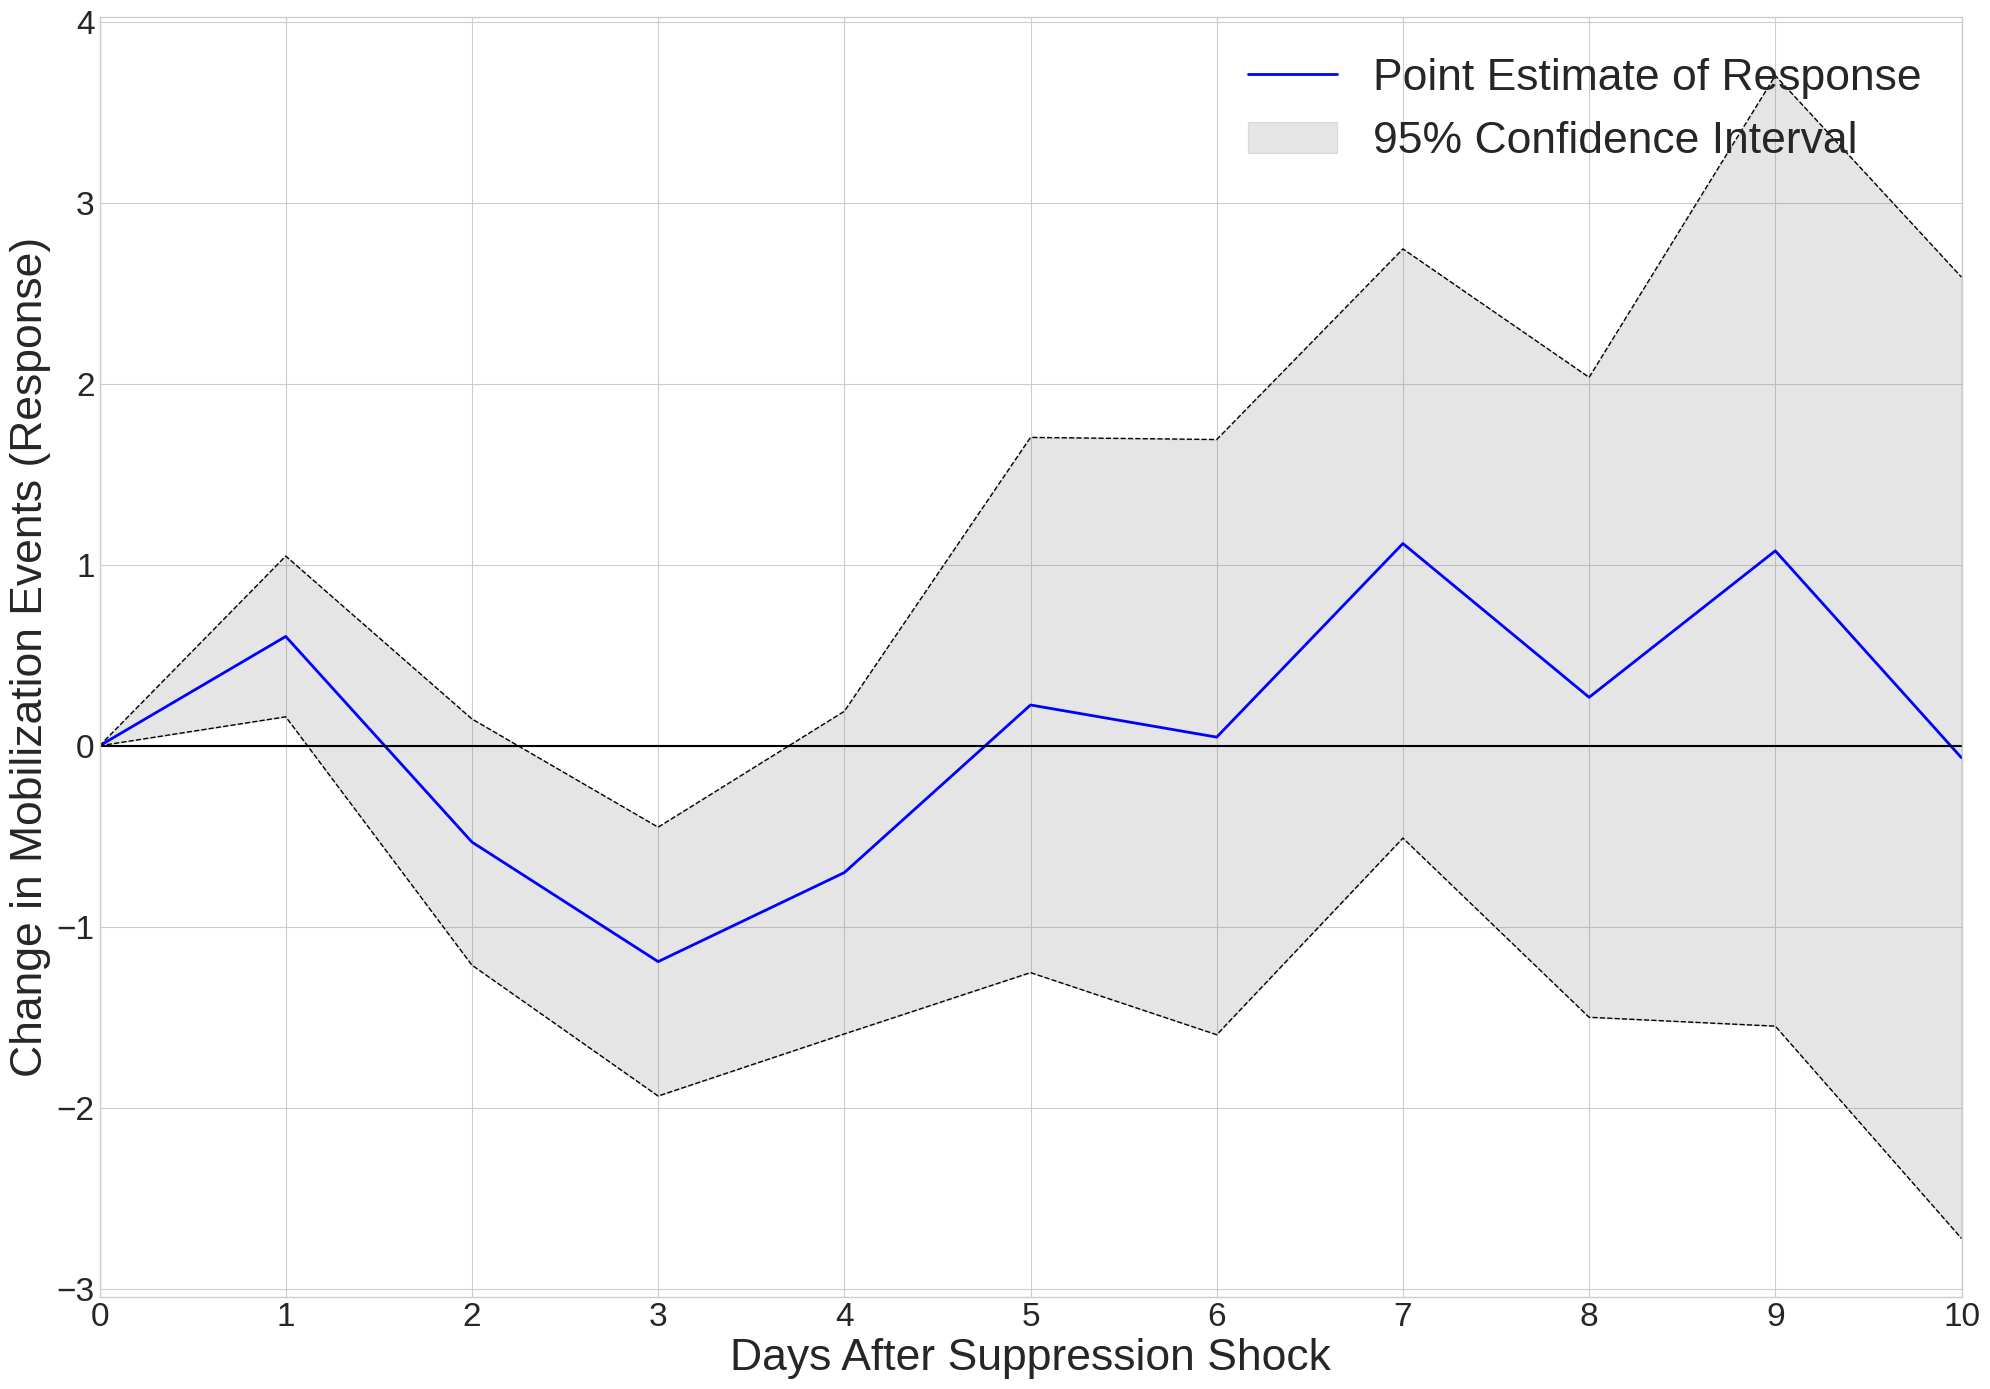

In [ ]:
# --- STEP 4: Generating & Visualizing the IRF ---
irf_stationary = results_stationary.irf(periods=10)

# --- Plotting Section ---
plt.style.use('seaborn-v0_8-whitegrid')

# 2. Extracting the core Statistical Components
impulse_var = 'fatalities_change'
response_var = 'mobilization_change'
horizon = 10 # Number of days to plot

# Getting the point estimate of the response
point_estimate = irf_stationary.irfs[:, results_stationary.names.index(response_var), results_stationary.names.index(impulse_var)]

# Getting the standard errors for the impulse responses
standard_errors = irf_stationary.stderr()[:, results_stationary.names.index(response_var), results_stationary.names.index(impulse_var)]

# 3. Calculating the 95% Confidence Interval
# For a 95% CI, the z-score is approximately 1.96
z_score = 1.96
lower_ci = point_estimate - z_score * standard_errors
upper_ci = point_estimate + z_score * standard_errors

# Creating an array for the x-axis (days)
x_axis = np.arange(horizon + 1)

# 4. The Plot
fig, ax = plt.subplots(figsize=(20, 14))

# Plotting the point estimate (the main response line)
ax.plot(x_axis, point_estimate, color='blue', linestyle='-', lw=2, label='Point Estimate of Response')

# Plotting the confidence interval as dashed lines
ax.plot(x_axis, lower_ci, color='black', linestyle='--', lw=1)
ax.plot(x_axis, upper_ci, color='black', linestyle='--', lw=1)

# Adding the transparent fill for the confidence interval
ax.fill_between(x_axis, lower_ci, upper_ci, color='gray', alpha=0.2, label='95% Confidence Interval')

# Further customization for Paper
ax.axhline(0, color='black', linestyle='-', lw=1.5)
ax.set_ylabel("Change in Mobilization Events (Response)", fontsize=32)
ax.set_xlabel("Days After Suppression Shock", fontsize=32)
#ax.set_title("Dynamic Response of Mobilization to a Suppression Shock", fontsize=16, weight='bold')
ax.set_xticks(np.arange(0, horizon + 1, 1))
ax.tick_params(axis='both', labelsize=24)
ax.set_xlim(0, horizon)
ax.legend(loc='upper right', fontsize=32)

plt.tight_layout()
plt.show()

# **Machine Learning Analysis with Additional Features**

## **XGBoost**


Performing Walk-Forward Validation for target: total_events (2-Day Lags)...

--- Walk-Forward Validation Metrics for total_events ---
Mean Absolute Error (MAE): 8.271
R-squared: 0.606
Root Mean Squared Error (RMSE): 14.425


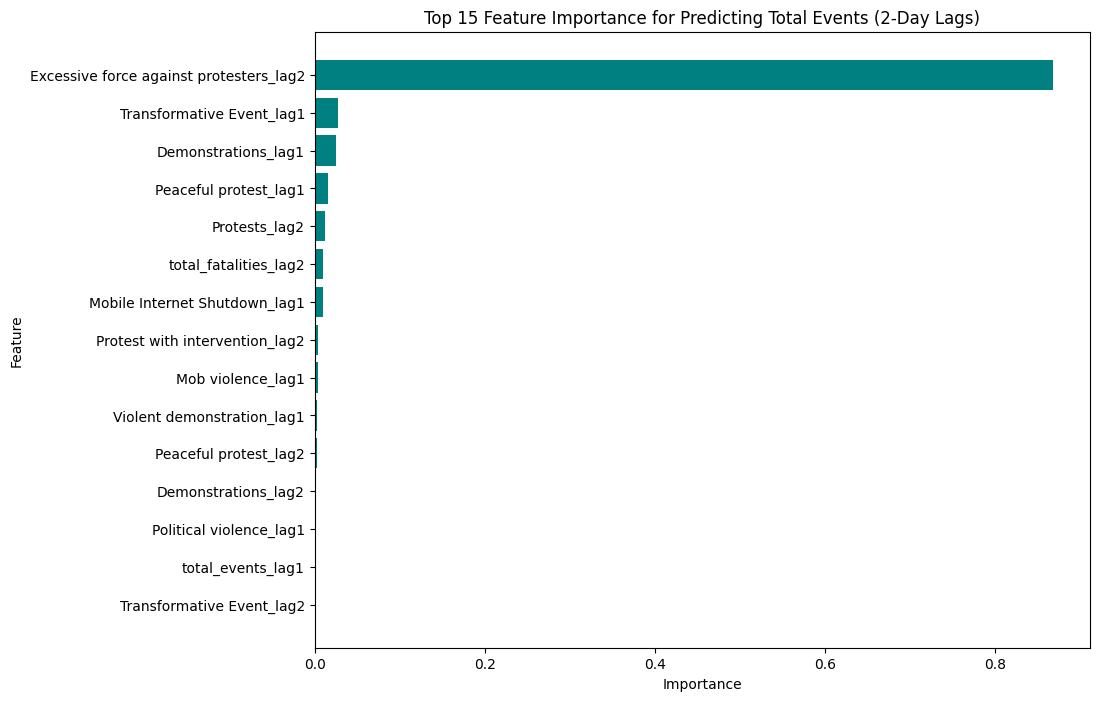


Performing Walk-Forward Validation for target: total_fatalities (2-Day Lags)...

--- Walk-Forward Validation Metrics for total_fatalities ---
Mean Absolute Error (MAE): 10.995
R-squared: 0.470
Root Mean Squared Error (RMSE): 26.364


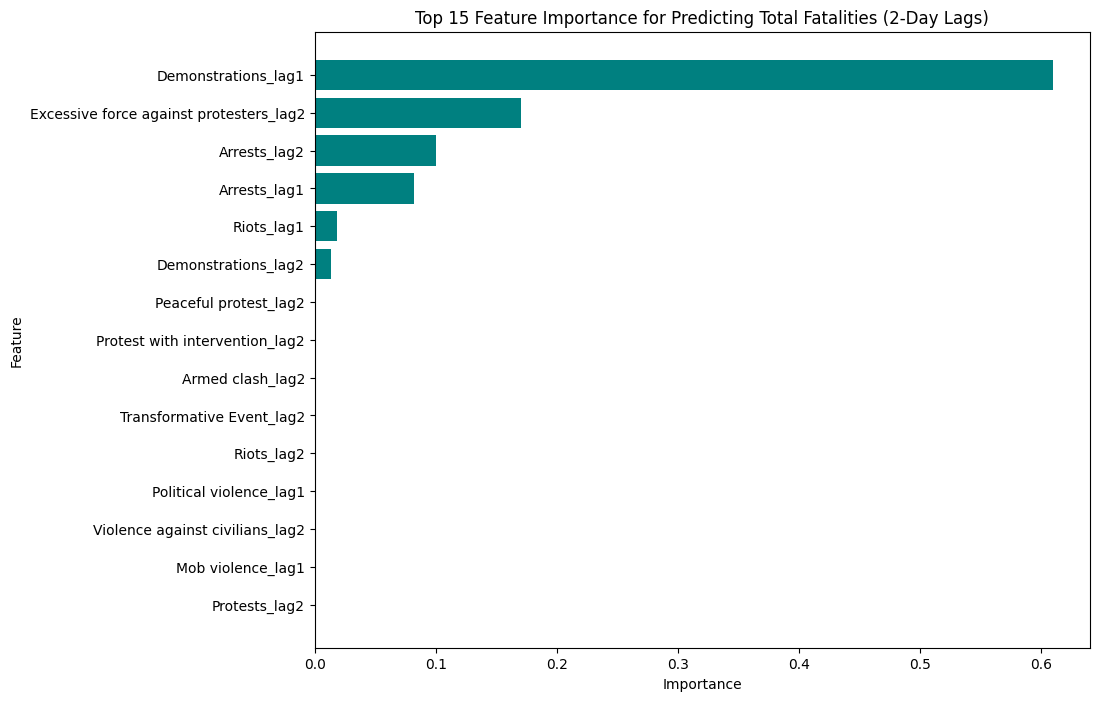

In [ ]:
# Loading the dataset
file_path = '/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_event_summary_with_new_columns_Reduced.csv'
df = pd.read_csv(file_path)

# Data cleaning and preparation
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(axis=1, how='all')
df['event_date'] = pd.to_datetime(df['event_date'])
df = df.sort_values('event_date')

# --- Feature engineering with 2-DAY LAGS ---
lag_features = []
lag_dfs = [df]
for column in df.columns:
    if column not in ['event_date', 'total_fatalities', 'total_events']:
        # Creating lags for 1 and 2 days
        for lag in range(1, 3):
            lagged_col = df[column].shift(lag).rename(f'{column}_lag{lag}')
            lag_dfs.append(lagged_col)
            lag_features.append(f'{column}_lag{lag}')
# Also creating 2-day lags for fatalities and events
for lag in range(1, 3):
    lagged_fatalities = df['total_fatalities'].shift(lag).rename(f'total_fatalities_lag{lag}')
    lagged_events = df['total_events'].shift(lag).rename(f'total_events_lag{lag}')
    lag_dfs.append(lagged_fatalities)
    lag_dfs.append(lagged_events)
    lag_features.append(f'total_fatalities_lag{lag}')
    lag_features.append(f'total_events_lag{lag}')

df = pd.concat(lag_dfs, axis=1)
df = df.dropna()

if df.empty:
    raise ValueError("The dataset is empty after dropping NaN values.")

# --- Function with Walk-Forward Validation ---
def train_and_plot_feature_importance(target, title):
    X = df[lag_features]
    y = df[target]

    if X.shape[0] <= 1:
        raise ValueError("Cannot perform validation with n_samples={}. Ensure there are enough samples.".format(X.shape[0]))

    print(f"\nPerforming Walk-Forward Validation for target: {target} (2-Day Lags)...")
    min_train_size = 10
    y_true, y_pred = [], []

    for i in range(min_train_size, len(X)):
        X_train, y_train = X.iloc[:i], y.iloc[:i]
        X_test, y_test = X.iloc[i:i+1], y.iloc[i:i+1]

        model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        model.fit(X_train, y_train)

        y_pred.append(model.predict(X_test)[0])
        y_true.append(y_test.values[0])

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n--- Walk-Forward Validation Metrics for {target} ---")
    print(f"Mean Absolute Error (MAE): {mae:.3f}")
    print(f"R-squared: {r2:.3f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
    print("="*50)

    final_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    final_model.fit(X, y)
    importances = final_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': lag_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    top_15_features = feature_importance_df.head(15)

    plt.figure(figsize=(10, 8))
    plt.barh(top_15_features['Feature'], top_15_features['Importance'], color='teal')
    plt.title(title)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis()
    plt.show()

# --- Running the full analysis with the 2-day lag specification ---
train_and_plot_feature_importance('total_events', 'Top 15 Feature Importance for Predicting Total Events (2-Day Lags)')
train_and_plot_feature_importance('total_fatalities', 'Top 15 Feature Importance for Predicting Total Fatalities (2-Day Lags)')


Performing Walk-Forward Validation for target: total_events (Final Curated Features)...

--- Walk-Forward Validation Metrics for total_events ---
Mean Absolute Error (MAE): 8.266
R-squared: 0.646
Root Mean Squared Error (RMSE): 13.664


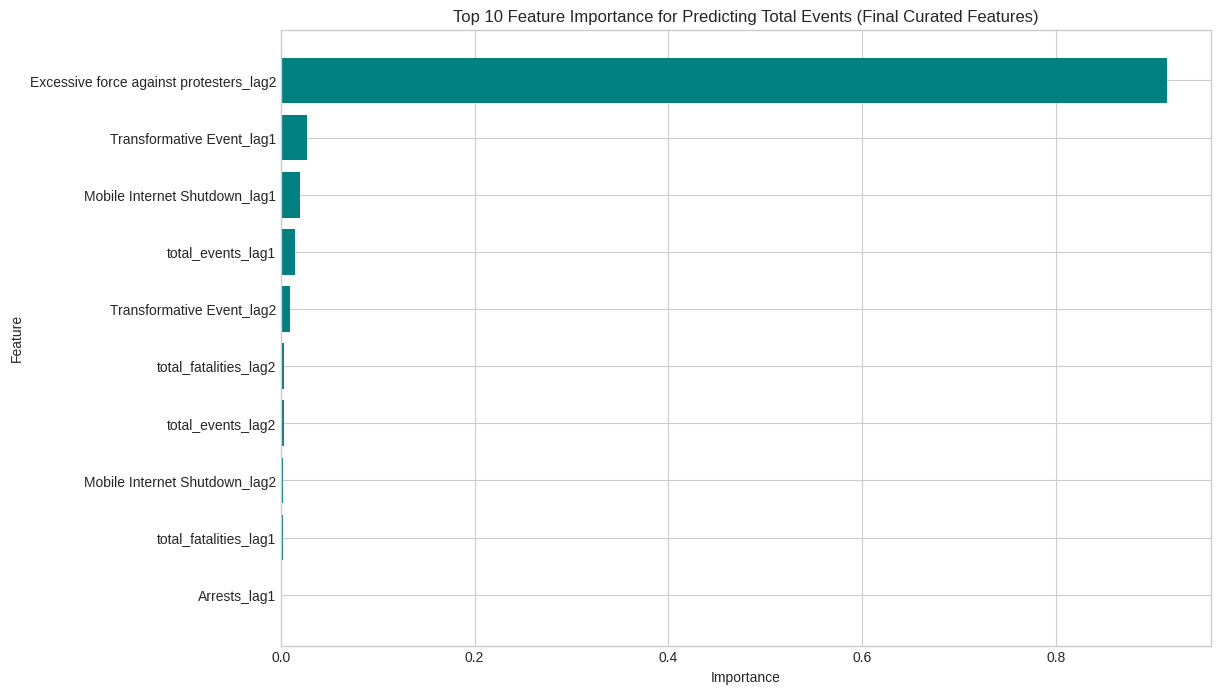


Performing Walk-Forward Validation for target: total_fatalities (Final Curated Features)...

--- Walk-Forward Validation Metrics for total_fatalities ---
Mean Absolute Error (MAE): 9.138
R-squared: 0.459
Root Mean Squared Error (RMSE): 26.629


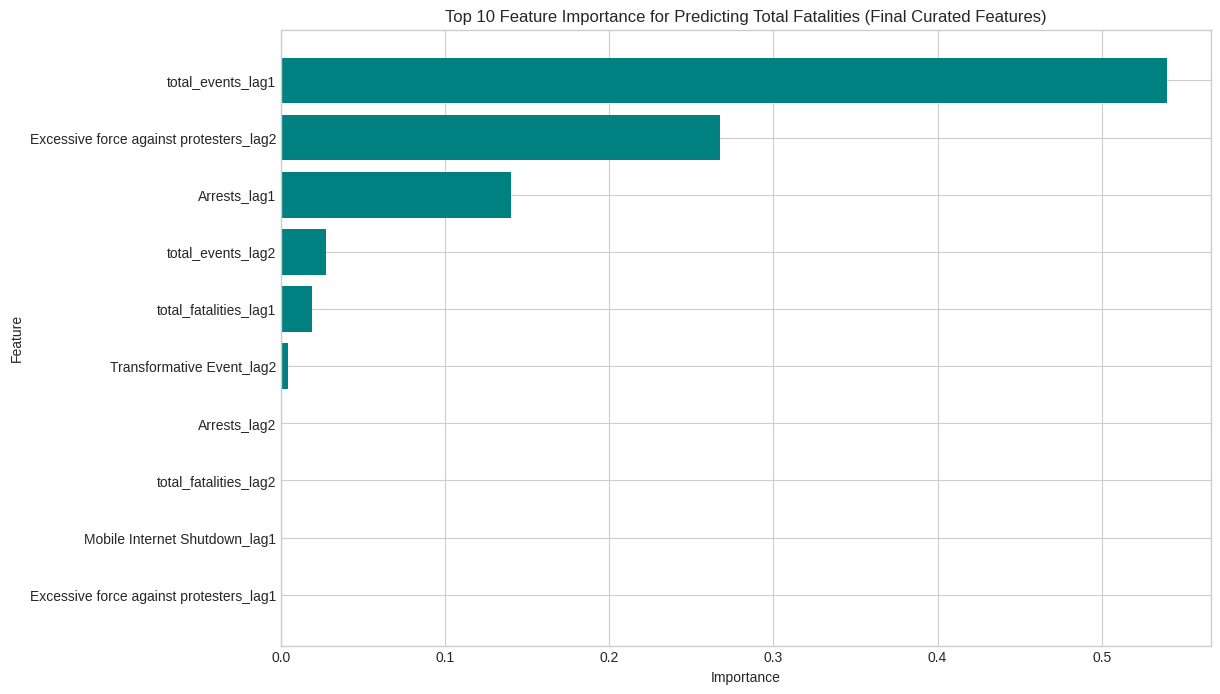

In [ ]:
# Loading the dataset
file_path = '/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_event_summary_with_new_columns_Reduced.csv'
df = pd.read_csv(file_path)

# Data cleaning and preparation
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(axis=1, how='all')
df['event_date'] = pd.to_datetime(df['event_date'])
df = df.sort_values('event_date')

# Feature engineering
core_predictors = [
    'total_events',
    #'Riots',
    'total_fatalities',
    'Arrests',
    'Excessive force against protesters',
    'Mobile Internet Shutdown',
    'Curfew',
    'Major Event'
]
lag_dfs = [df]
lag_features = []
for column in core_predictors:
    for lag in range(1, 3): # 2-day lag
        lagged_col = df[column].shift(lag).rename(f'{column}_lag{lag}')
        lag_dfs.append(lagged_col)
        lag_features.append(f'{column}_lag{lag}')
df = pd.concat(lag_dfs, axis=1)
df = df.dropna()

# --- The main analysis function ---
def train_and_plot_feature_importance(target, title):
    X = df[lag_features]
    y = df[target]

    print(f"\nPerforming Walk-Forward Validation for target: {target} (Final Curated Features)...")
    min_train_size = 10
    y_true, y_pred = [], []

    for i in range(min_train_size, len(X)):
        X_train, y_train = X.iloc[:i], y.iloc[:i]
        X_test, y_test = X.iloc[i:i+1], y.iloc[i:i+1]
        model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        model.fit(X_train, y_train)
        y_pred.append(model.predict(X_test)[0])
        y_true.append(y_test.values[0])

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n--- Walk-Forward Validation Metrics for {target} ---")
    print(f"Mean Absolute Error (MAE): {mae:.3f}")
    print(f"R-squared: {r2:.3f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
    print("="*50)

    final_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    final_model.fit(X, y)
    importances = final_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': lag_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

    # --- Selecting only the TOP 10 features for the plot ---
    top_10_features = feature_importance_df.head(10)

    # Plotting the top 10 most important features
    plt.figure(figsize=(12, 8))
    plt.barh(top_10_features['Feature'], top_10_features['Importance'], color='teal')
    plt.title(title)
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis()
    plt.show()

# Running the final, curated analysis
train_and_plot_feature_importance('total_events', 'Top 10 Feature Importance for Predicting Total Events (Final Curated Features)')
train_and_plot_feature_importance('total_fatalities', 'Top 10 Feature Importance for Predicting Total Fatalities (Final Curated Features)')

## **Combining Lagged Features**


Performing Walk-Forward Validation for target: total_events (Final Curated Features)...

--- Walk-Forward Validation Metrics for total_events ---
MAE: 8.266
R²: 0.646
RMSE: 13.664

--- Aggregated Importance (Lag1 + Lag2) ---
                          BaseFeature  Importance
2  Excessive force against protesters    0.914935
4                Transformative Event    0.036287
3            Mobile Internet Shutdown    0.022640
5                        total_events    0.017587
6                    total_fatalities    0.005088
0                             Arrests    0.002284
1                              Curfew    0.001179


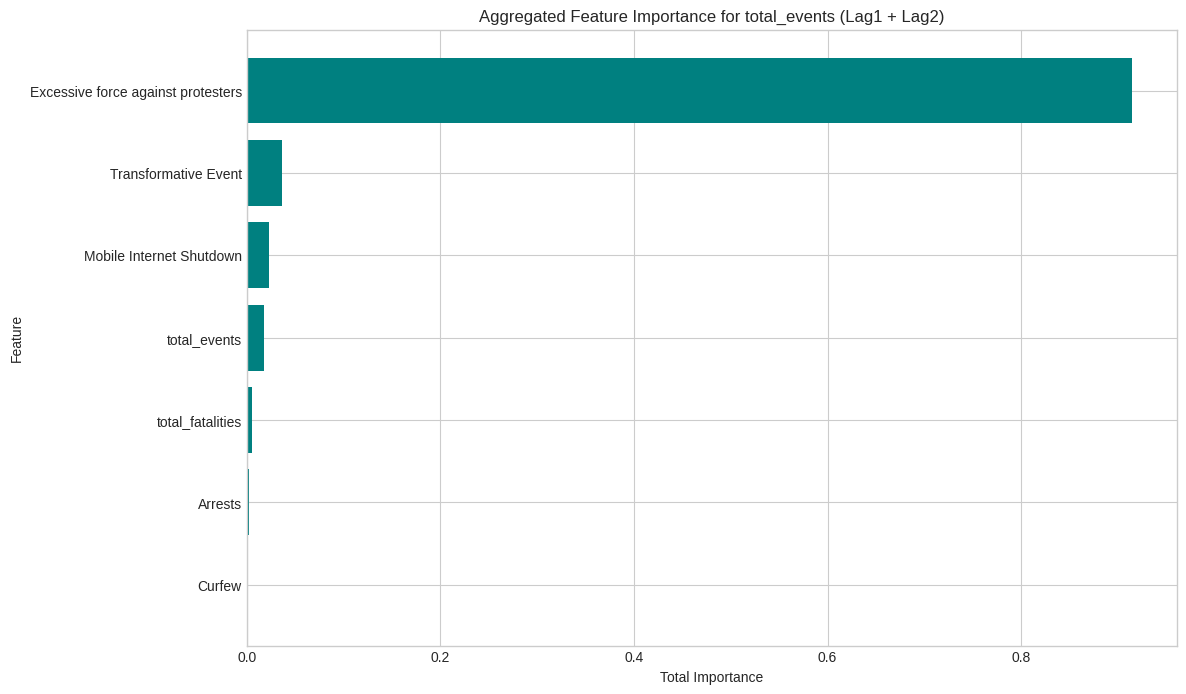

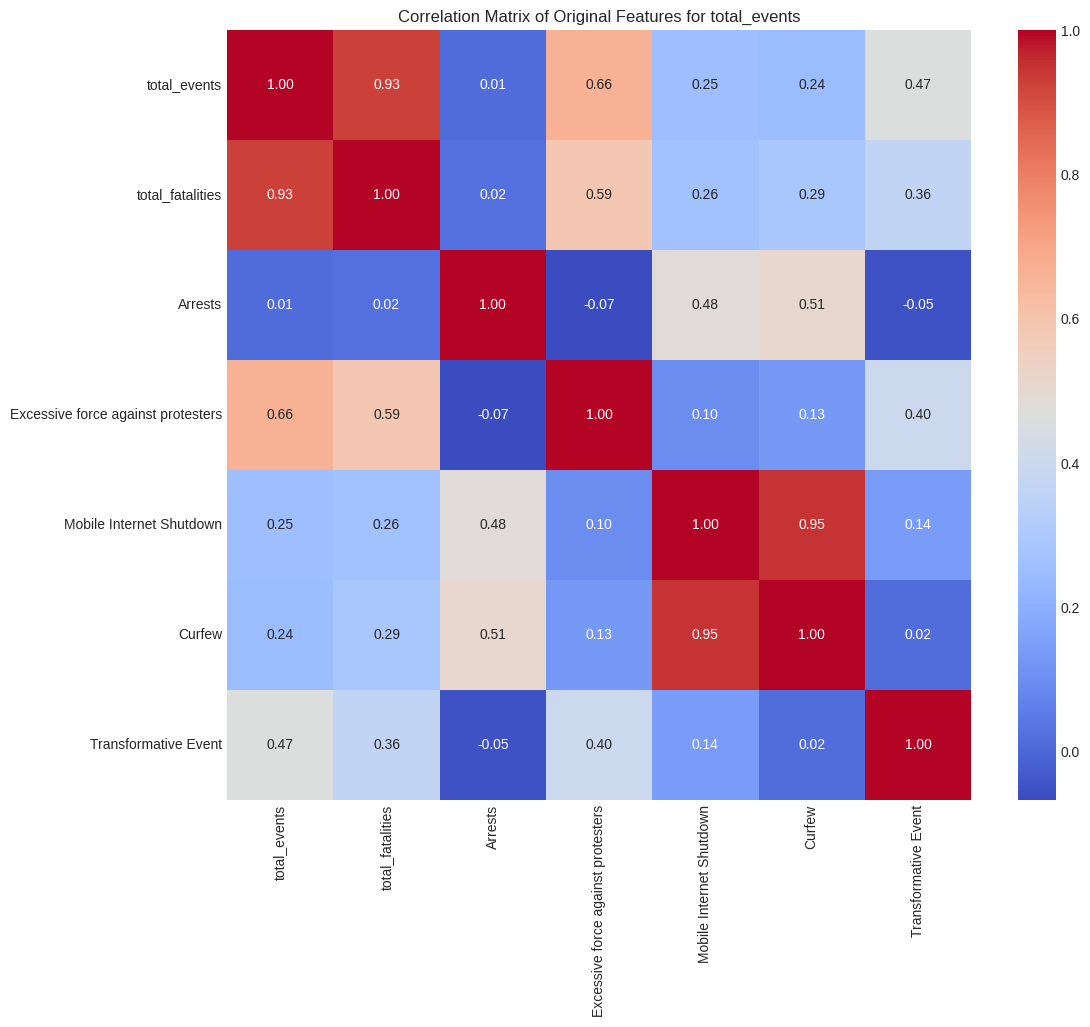


Performing Walk-Forward Validation for target: total_fatalities (Final Curated Features)...

--- Walk-Forward Validation Metrics for total_fatalities ---
MAE: 9.138
R²: 0.459
RMSE: 26.629

--- Aggregated Importance (Lag1 + Lag2) ---
                          BaseFeature  Importance
5                        total_events    0.567201
2  Excessive force against protesters    0.267986
0                             Arrests    0.140538
6                    total_fatalities    0.019128
4                Transformative Event    0.004517
3            Mobile Internet Shutdown    0.000630
1                              Curfew    0.000000


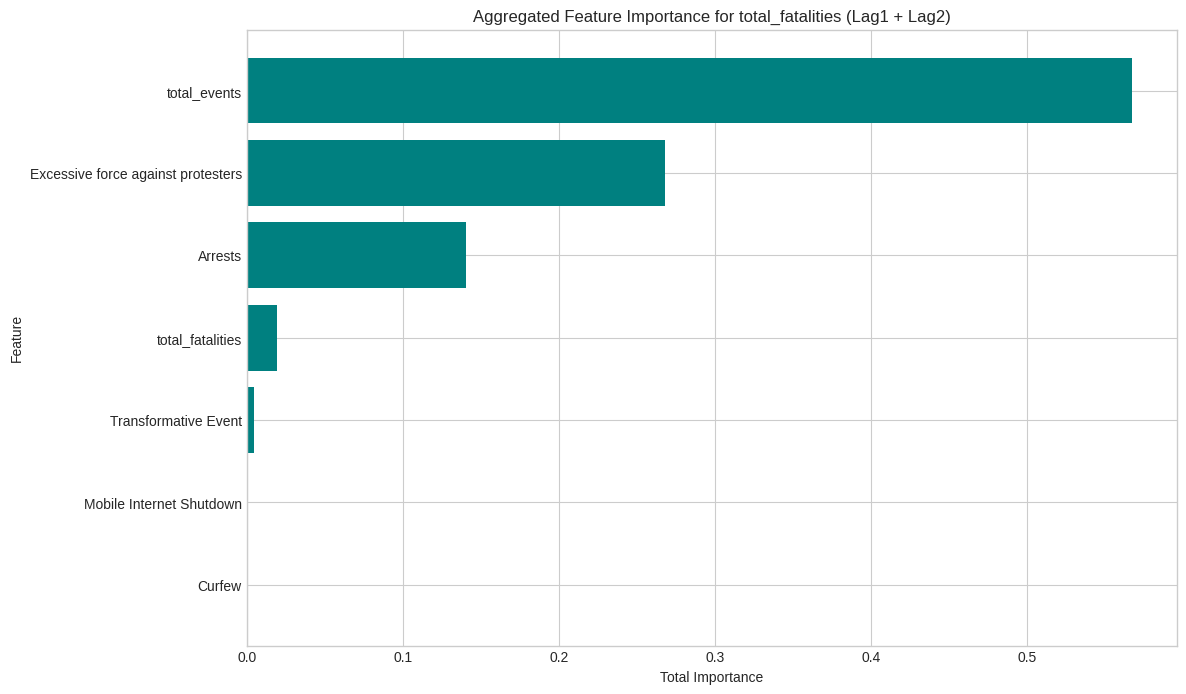

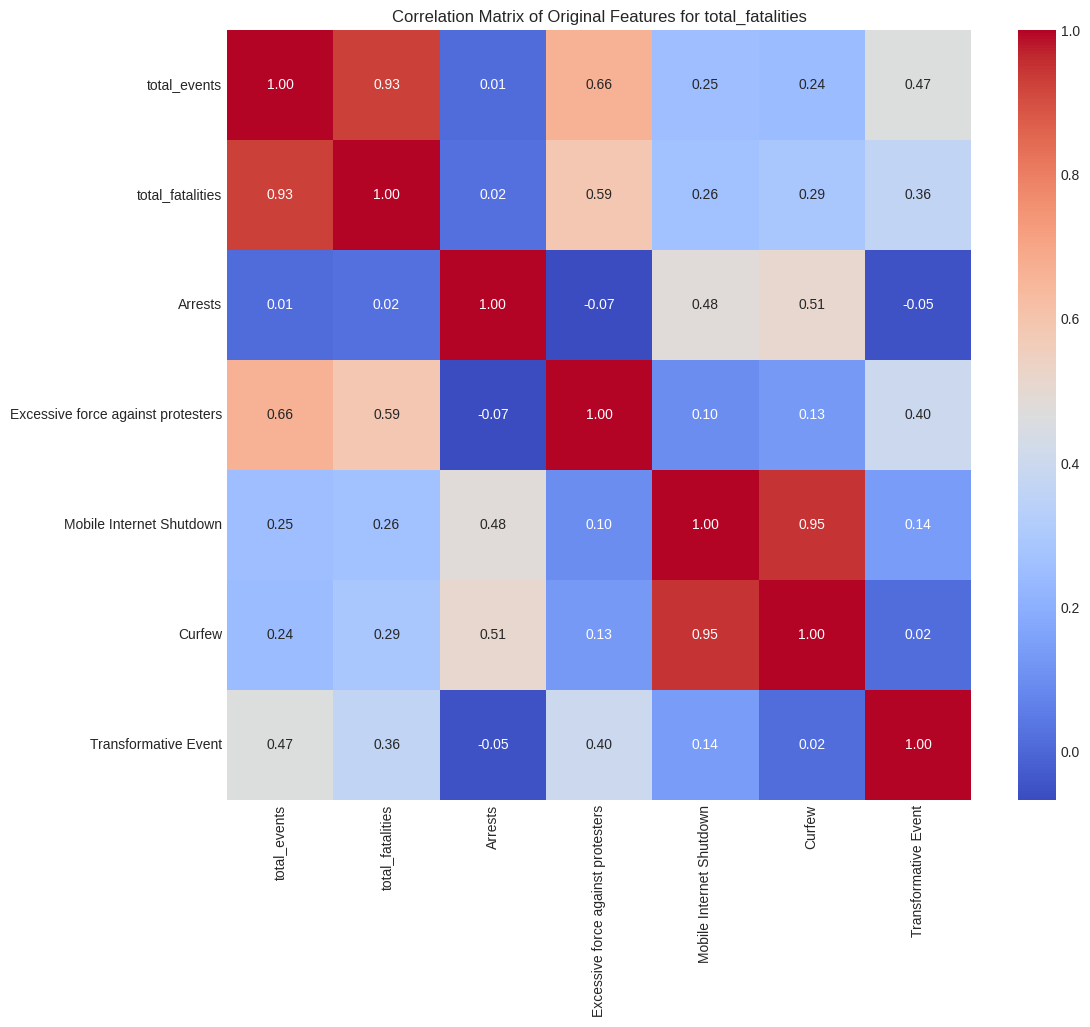

In [ ]:
def train_and_plot_feature_importance(target, title):
    X = df[lag_features]
    y = df[target]

    print(f"\nPerforming Walk-Forward Validation for target: {target} (Final Curated Features)...")
    min_train_size = 10
    y_true, y_pred = [], []

    for i in range(min_train_size, len(X)):
        X_train, y_train = X.iloc[:i], y.iloc[:i]
        X_test, y_test = X.iloc[i:i+1], y.iloc[i:i+1]
        model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
        model.fit(X_train, y_train)
        y_pred.append(model.predict(X_test)[0])
        y_true.append(y_test.values[0])

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n--- Walk-Forward Validation Metrics for {target} ---")
    print(f"MAE: {mae:.3f}")
    print(f"R²: {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print("="*50)

    # --- Training final model on all data ---
    final_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
    final_model.fit(X, y)
    importances = final_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': lag_features, 'Importance': importances})

    # --- Aggregating lag1 + lag2 for each base feature ---
    feature_importance_df['BaseFeature'] = feature_importance_df['Feature'].str.replace(r'_lag\d+', '', regex=True)
    aggregated_importance = (
        feature_importance_df.groupby('BaseFeature')['Importance']
        .sum()
        .reset_index()
        .sort_values(by='Importance', ascending=False)
    )

    print("\n--- Aggregated Importance (Lag1 + Lag2) ---")
    print(aggregated_importance)

    # --- Plotting aggregated importance ---
    plt.figure(figsize=(12, 8))
    plt.barh(aggregated_importance['BaseFeature'], aggregated_importance['Importance'], color='teal')
    plt.title(f'Aggregated Feature Importance for {target} (Lag1 + Lag2)')
    plt.xlabel('Total Importance')
    plt.ylabel('Feature')
    plt.gca().invert_yaxis()
    plt.show()

    # --- Correlation matrix for original (non-lagged) features ---
    plt.figure(figsize=(12, 10))
    corr_matrix = df[core_predictors].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
    plt.title(f'Correlation Matrix of Original Features for {target}')
    plt.show()

# Running the analysis
train_and_plot_feature_importance('total_events', 'Top 10 Feature Importance for Predicting Total Events (Final Curated Features)')
train_and_plot_feature_importance('total_fatalities', 'Top 10 Feature Importance for Predicting Total Fatalities (Final Curated Features)')


## **Random Forest**


Performing Walk-Forward Validation for target: total_events (Random Forest, Final Curated Features)...

--- Walk-Forward Validation Metrics for total_events ---
MAE: 8.402
R²: 0.520
RMSE: 15.918
Saving the final Random Forest model to RF_model_July.pkl...
Model saved successfully.

--- Aggregated Importance (Lag1 + Lag2) ---
                           BaseFeature  Importance
2  Excessive force\nagainst protesters    0.527710
5                         total_events    0.266768
6                     total_fatalities    0.103316
3                          Major Event    0.077260
4            Mobile Internet\nShutdown    0.011557
1                               Curfew    0.009604
0                              Arrests    0.003785


/tmp/ipython-input-3099225160.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='BaseFeature', data=aggregated_importance.head(7), palette='mako')


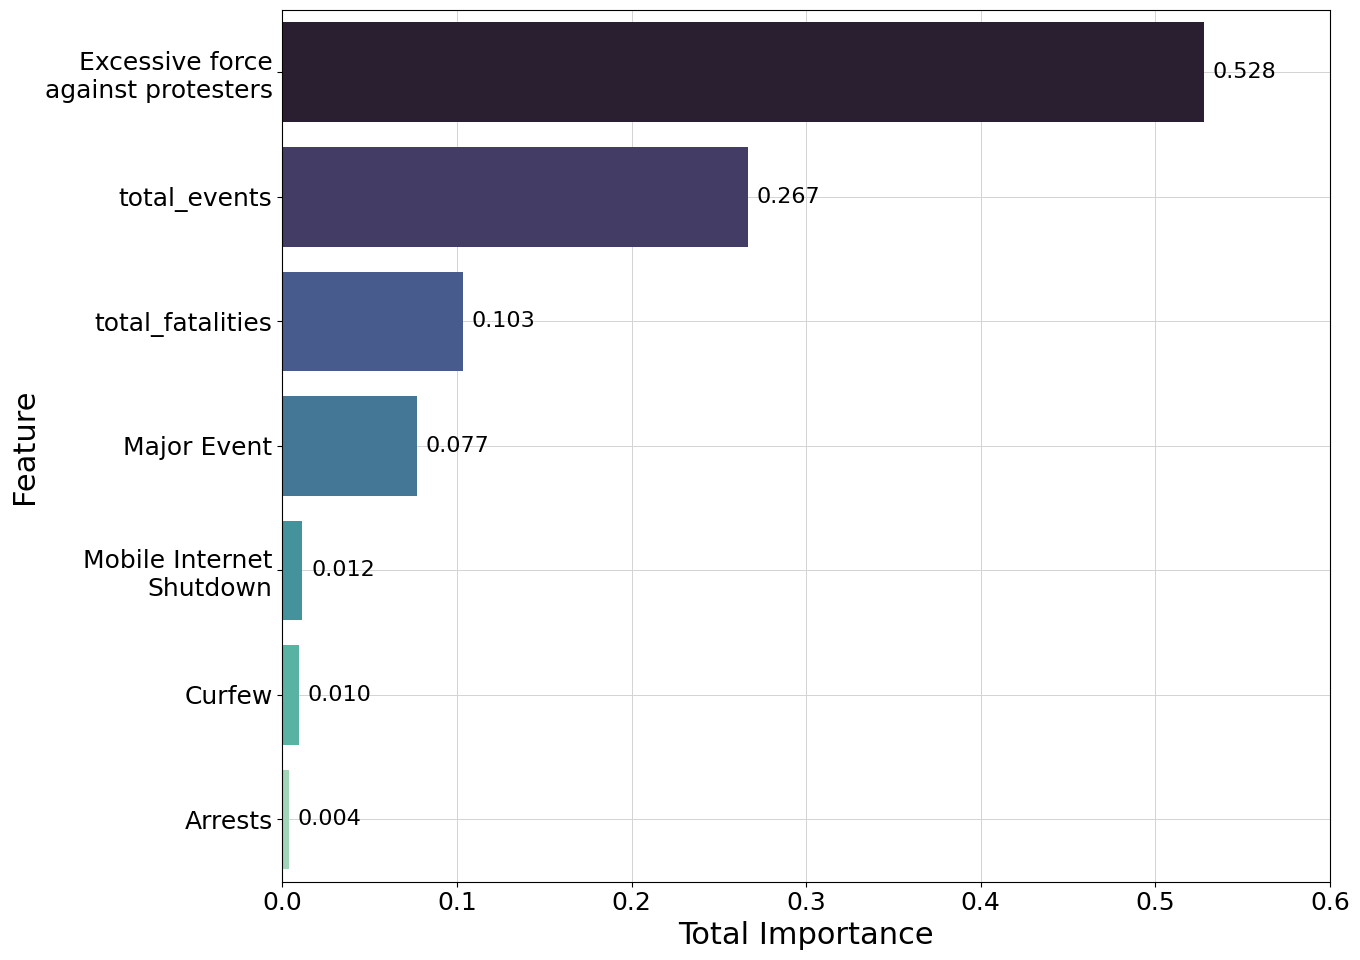

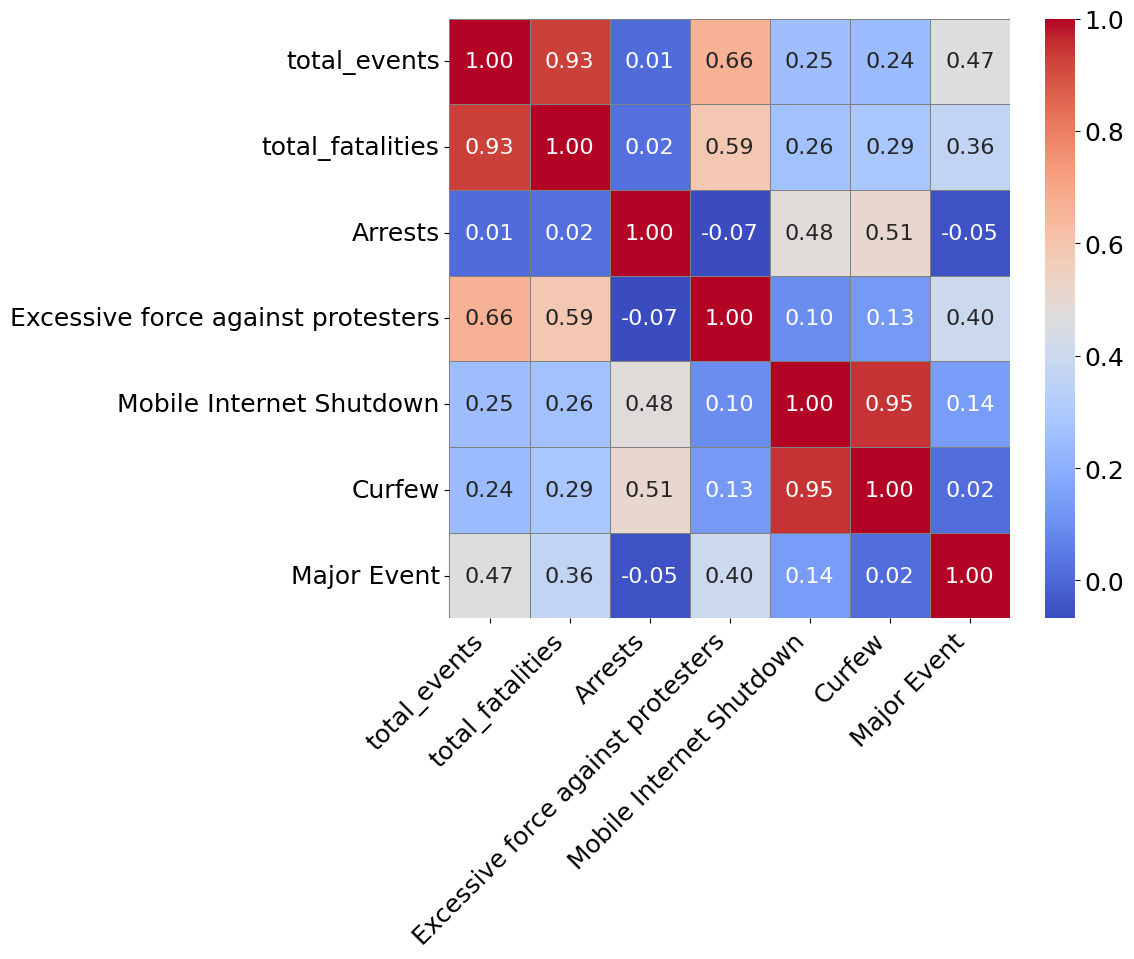


Performing Walk-Forward Validation for target: total_fatalities (Random Forest, Final Curated Features)...

--- Walk-Forward Validation Metrics for total_fatalities ---
MAE: 9.803
R²: 0.495
RMSE: 25.734
Saving the final Random Forest model to RF_model_July.pkl...
Model saved successfully.

--- Aggregated Importance (Lag1 + Lag2) ---
                           BaseFeature  Importance
5                         total_events    0.606565
2  Excessive force\nagainst protesters    0.221612
6                     total_fatalities    0.151430
3                          Major Event    0.007017
1                               Curfew    0.006077
4            Mobile Internet\nShutdown    0.004318
0                              Arrests    0.002981


/tmp/ipython-input-3099225160.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='BaseFeature', data=aggregated_importance.head(7), palette='mako')


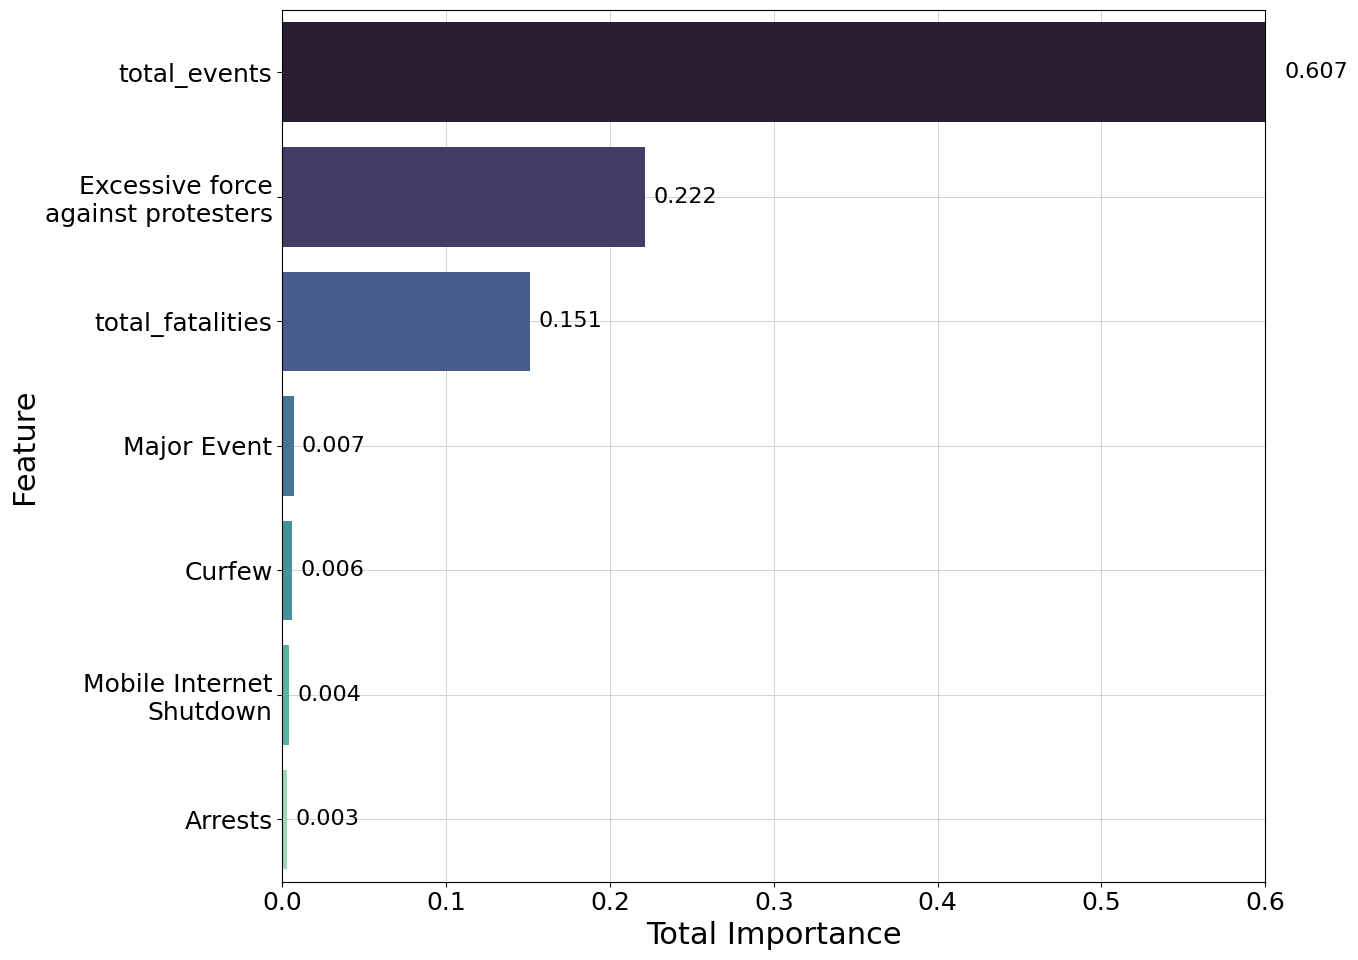

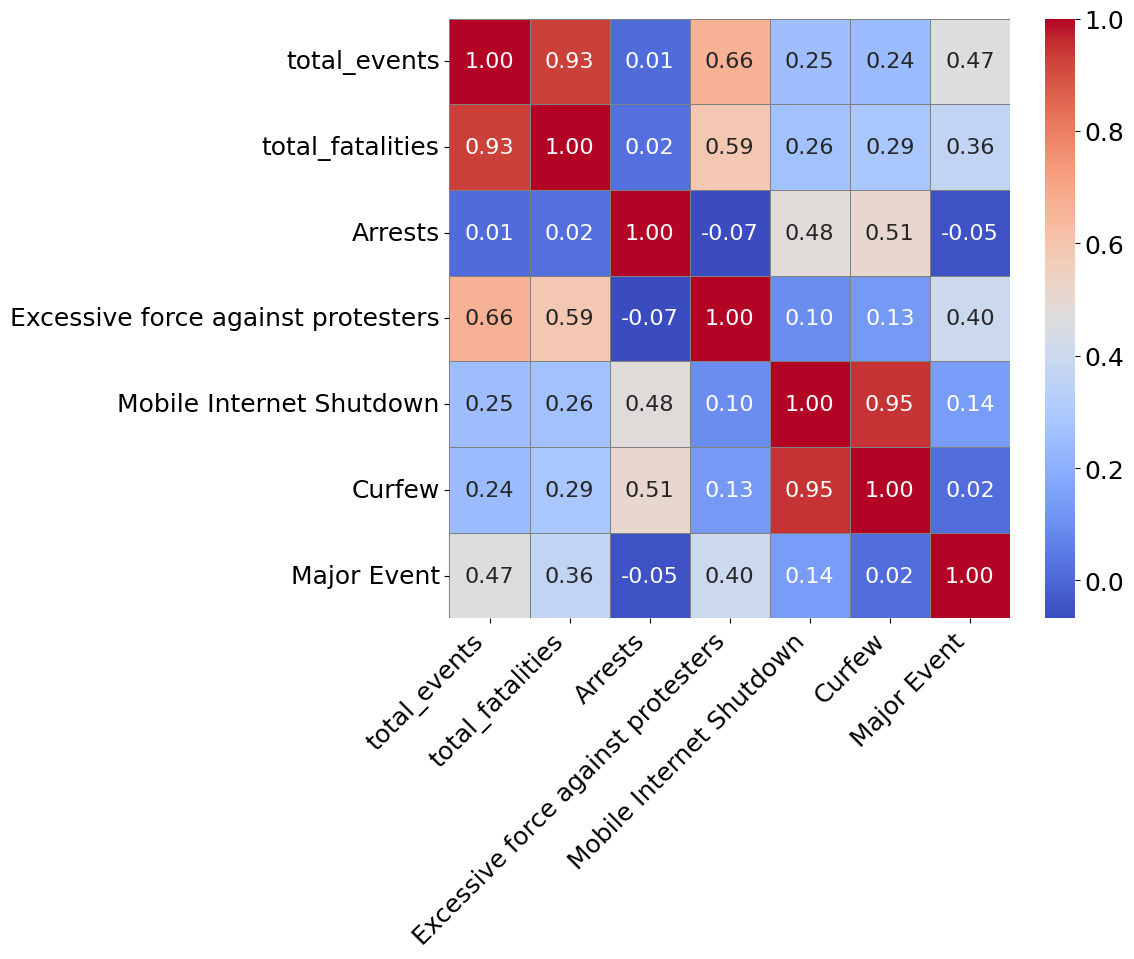

In [5]:
# --- GLOBAL FONT SETTINGS (To add to the paper. Modify these for a better view on the Notebook) ---
plt.rcParams.update({
    'font.size': 20,
    'axes.titlesize': 24,
    'axes.labelsize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18
})

# Loading the dataset
file_path = '/content/drive/MyDrive/Research/Bangladesh Movement Research/daily_event_summary_with_new_columns_Reduced.csv'
df = pd.read_csv(file_path)

# Data cleaning and preparation
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df = df.dropna(axis=1, how='all')
df['event_date'] = pd.to_datetime(df['event_date'])
df = df.sort_values('event_date')

# Feature engineering
core_predictors = [
    'total_events',
    'total_fatalities',
    'Arrests',
    'Excessive force against protesters',
    'Mobile Internet Shutdown',
    'Curfew',
    'Major Event'
]
lag_dfs = [df]
lag_features = []
for column in core_predictors:
    for lag in range(1, 3):
        lagged_col = df[column].shift(lag).rename(f'{column}_lag{lag}')
        lag_dfs.append(lagged_col)
        lag_features.append(f'{column}_lag{lag}')
df = pd.concat(lag_dfs, axis=1)
df = df.dropna()

# --- Main analysis function ---
def train_and_plot_feature_importance(target, title):
    X = df[lag_features]
    y = df[target]

    print(f"\nPerforming Walk-Forward Validation for target: {target} (Random Forest, Final Curated Features)...")
    min_train_size = 10
    y_true, y_pred = [], []

    for i in range(min_train_size, len(X)):
        X_train, y_train = X.iloc[:i], y.iloc[:i]
        X_test, y_test = X.iloc[i:i+1], y.iloc[i:i+1]

        model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)

        y_pred.append(model.predict(X_test)[0])
        y_true.append(y_test.values[0])

    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print(f"\n--- Walk-Forward Validation Metrics for {target} ---")
    print(f"MAE: {mae:.3f}")
    print(f"R²: {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print("="*50)

    # Final model for feature importance
    final_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    final_model.fit(X, y)
    importances = final_model.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': lag_features, 'Importance': importances})

    # --- SAVING THE FINAL MODEL ---
    RF_MODEL_PATH = "RF_model_July.pkl"
    print(f"Saving the final Random Forest model to {RF_MODEL_PATH}...")
    joblib.dump(final_model, RF_MODEL_PATH)
    print("Model saved successfully.")

    # Aggregating lag1 + lag2 for each base feature
    feature_importance_df['BaseFeature'] = feature_importance_df['Feature'].str.replace(r'_lag\d+', '', regex=True)
    aggregated_importance = (
        feature_importance_df.groupby('BaseFeature')['Importance']
        .sum()
        .reset_index()
        .sort_values(by='Importance', ascending=False)
    )

    # Wrapping long feature names
    aggregated_importance['BaseFeature'] = aggregated_importance['BaseFeature'].apply(
        lambda x: '\n'.join(textwrap.wrap(x, width=18))
    )

    print("\n--- Aggregated Importance (Lag1 + Lag2) ---")
    print(aggregated_importance)

    fig, ax = plt.subplots(figsize=(14, 10))
    bars = ax.barh(aggregated_importance['BaseFeature'], aggregated_importance['Importance'], color='navy')
    sns.barplot(x='Importance', y='BaseFeature', data=aggregated_importance.head(7), palette='mako')
    #ax.set_title(f'Aggregated Feature Importance for {target} (Lag1 + Lag2, RF)')
    ax.set_xlabel('Total Importance')
    ax.set_ylabel('Feature')
    ax.set_xlim(0, 0.6)

    # Solid light grid on both axes
    ax.set_axisbelow(True)
    ax.grid(True, which='both', axis='both', color='lightgray', linestyle='-', linewidth=0.7)

    # Adding value labels
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                f"{width:.3f}", va='center', fontsize=16)

    plt.tight_layout()
    plt.show()


    # Correlation matrix for original features with grid
    fig, ax = plt.subplots(figsize=(12, 10))
    corr_matrix = df[core_predictors].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True,
                annot_kws={"size": 16}, ax=ax, linewidths=0.5, linecolor='gray')
    #ax.set_title(f'Correlation Matrix of Original Features for {target}')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Running the analysis
train_and_plot_feature_importance('total_events', 'Aggregated Feature Importance for Predicting Total Events (RF)')
train_and_plot_feature_importance('total_fatalities', 'Aggregated Feature Importance for Predicting Total Fatalities (RF)')
